<a href="https://colab.research.google.com/github/corsinioliver-sudo/madonna-con-il-bambino/blob/main/Analisi_della_rappresentazione_artistica_dell'iconografia_della_Madonna_col_Bambino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# Analisi della rappresentazione artistica dell'iconografia della Madonna col Bambino

## 1. Introduzione

Il progetto analizza un dataset di metadati estratti da Wikidata di opere d'arte visiva presenti in Italia. Dopo una prima esplorazione generale del dataset, l'attenzione si concentra sulle opere che usano l'iconografia della Madonna col Bambino. Su questo sottoinsieme vengono analizzate tre dimensioni: il periodo storico (secolo) in cui essa è stata maggiormente rappresentata, il genere artistico che utilizza più spesso questa iconogrfia e gli artisti che, all'interno del datset, ricorrono più frequentemente a questo soggetto. L'analisi permette così di comprendere la diffusione e l'evoluzione di questa iconografia nel contesto storico-artistico italiano.







### 1.1. Obiettivi
1. In quale periodo storico (secolo) è stato elaborato il maggior numero di opere con l'iconografia della Madonna col Bambino?
2. In quale genere artistico prevale l'iconografia della Madonna col Bambino?
3. Qual'è l'artista presente all'interno del daset che ha maggiormente utilizzato questa iconografia?

### 1.2. Dati utilizzati
Abbiamo utilizzato il DataSet estratto da WikiData. I dati sono stati recuperati dal repository di GitHub di sbrzt (https://github.com/dhdmch/2025-2026/tree/main/data/vapod). I dati sono costituiti da un file csv, formato da 12 colonne e 2444 righe, contenente le seguenti variabili:



| Variabile | Tipo |	Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
|     id | object | ID del quadro | http://www.wikidata.org/entity/Q29015025 |    
|titolo	 |object  |titolo dell'opera 	 |Betsabea|
|artisti|object|nome e genere dell'artista|Artemisia Gentileschi (femmina)|
|data_creazione|object|data dell'opera|1640-1645|
|generi|object|genere artistico dell'opera|nudo artistico;arte di genere; arte religiosa|
|luoghi|object|luogo di conservazione|Italia|
|collezioni|object|collezione in cui si trova l'opera|NaN|
|contenuti|object|elementi rappresentati nell'opera|donna;nudità;albero...|
|movimenti|object|movimento artistico|NaN|
|soggetti|object|soggetto rappresentato|Bestabea al bagno|
|altezza|float64|altezza dell'opera|288.0|
|larghezza|float64|larghezza dell'opera|228.0|

Link al dataset: https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csvDefinizione

### 1.3. Organizzazione

I dati in output verranno lavorati su Google Colab, utilizzando il linguaggio di programmazione Python, e la libreria Pandas.

### 1.4. Preservazione

I dati in output verranno conservati in un repository Github e archiviati Zenodo.

### 1.5. Accesso e Utilizzo

I dati in input sono rilasciati sotto licenza CC0 1.0 Universal.
Il codice rilasciato sotto licenza CC0 1.0 Universal.
I dati di output sono rilasciati sotto licenza CC0 1.0 Universal.


## 2. Struttura

* Introduzione
* Caricamento e ispezione dei dati
* Processamento dei dati
* Analisi dei dati
  * Exploratory Data Analysis
  * Explanatory Data Analysis
* Conclusione

## 3. Caricamento e ispezione dei dati




Per prima cosa importiamo la libreria pandas e la rinominiamo come "pd". Dopodichè importiamo il dataset come file csv.




In [ ]:
 import pandas as pd

In [ ]:
 df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")

In [ ]:
df

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0


Ora procediamo con l'ispezione dei dati. Per prima cosa analizziamo quante righe e colonne sono presenti nel dataset per farci una idea generale del numero di dati e metadati con cui dovremmo lavorare.

In [ ]:
 df.shape

(2444, 12)

Dopo aver analizzato le dimensioni della tabella, usiamo il metodo `.duplicated()` per controllare la presenza dei valori duplicati nella tabella

In [ ]:
print(df.duplicated().value_counts())

False    2444
Name: count, dtype: int64


Ci ha ritornato la risposta `False: 2444`. Il numero delle righe della tabella uguale a 2444 e il valore `False` significa che i duplicati non ci sono.

Il passaggio successivo è quello di controllare il titolo di ogni colonna e i dati in esse presenti

In [ ]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

Successivamente attraverso il metodo `.info()` analizziamo le celle della tabella identificando quante sono vuote (hanno i valori nulli) e quante no.


In [ ]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


Mediante i metodi `.head()` e `.tail()` si riescono a prendere in analisi i primi sette e gli ultimi dieci righe del dataset





In [ ]:
 df.head(7)

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0
5,http://www.wikidata.org/entity/Q488825,Adorazione dei Magi,Sandro Botticelli (maschio),1475,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; Sandro Botticelli; Laurus nobilis; Giov...,Primo Rinascimento; pittura rinascimentale ita...,Adorazione dei Magi,111.0,134.0
6,http://www.wikidata.org/entity/Q532486,Giuditta con la sua ancella,Artemisia Gentileschi (femmina),1610,arte religiosa,Palazzo Pitti,Galleria Palatina,Giuditta e Oloferne; Giuditta,NaN,Giuditta e Oloferne,114.0,93.5


In [ ]:
df.tail(10)

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2434,http://www.wikidata.org/entity/Q136807706,Cristo e l'adultera,Giovanni Cariani (maschio),1520,arte religiosa,deposito del museo,Accademia Carrara,Gesù; paesaggio; pericope dell'adultera; grupp...,pittura veneta; Alto Rinascimento,pericope dell'adultera,149.0,219.0
2435,http://www.wikidata.org/entity/Q136752887,Leda e il cigno,NaN,1568,nudo artistico; pittura mitologica,Galleria Sabauda,Galleria Sabauda; Collezione Riccardo Gualino ...,cielo; Cupido; mammella; nudità; capelli lungh...,pittura veneta,Leda e il cigno,124.0,107.0
2436,http://www.wikidata.org/entity/Q136840231,Venere allo specchio,Tiziano Vecellio (maschio),1600,nudo artistico; pittura mitologica,Galleria Giorgio Franchetti alla Ca' d'Oro,Galleria Giorgio Franchetti alla Ca' d'Oro,mammella; capelli lunghi; perla; ombelico; Ven...,pittura veneta,NaN,115.0,84.0
2437,http://www.wikidata.org/entity/Q137268771,Madonna orante,Giovanni Battista Salvi (maschio),1640,arte religiosa,deposito del museo,Collezione Lochis; Accademia Carrara,Maria; preghiera; aureola,NaN,Maria,47.0,37.0
2438,http://www.wikidata.org/entity/Q137040888,San Gerolamo penitente,Tiziano Vecellio (maschio),1600,arte religiosa,Accademia nazionale di San Luca,Accademia nazionale di San Luca,leone; libro; albero; crocifisso; cranio umano...,pittura veneta,San Girolamo nel deserto,107.5,76.5
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0


##4. Analisi e processamento  dei dati


### 4.1 Filtro dei dati

Come primo procedimento è stata definita la funzione di tipo conditional denominata `filtro_contenuti` successivamente applicato al dataset tramite il metodo `.apply()`: questa operazione ha permesso la creazione di una nuova colonna chiamata `contenuti_filtrati ` contenente esclusivamente i valori idoneo o nullo.






In [ ]:
def filtro_contenuti(contenuti):
    contents_str = str(contenuti)
    if 'Madonna' in contents_str:
        return 'idoneo'
    elif 'Bambino' in contents_str:
        return 'idoneo'
    elif 'Maria' in contents_str:
        return 'idoneo'
    elif 'madre' in contents_str:
        return 'idoneo'
    elif 'bambino' in contents_str:
        return 'idoneo'
    elif 'figlio' in contents_str:
      return 'idoneo'
    elif 'Gesù' in contents_str:
      return 'idoneo'
    elif 'donna' in contents_str:
      return 'idoneo'
    elif 'ragazzo' in contents_str:
      return 'idoneo'
    else:
        return 'nan'

In [ ]:
df['contenuti_filtrati'] = df['contenuti'].apply(filtro_contenuti)

In [ ]:
df

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0,nan
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,idoneo
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0,nan
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,idoneo
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,idoneo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0,idoneo
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0,nan
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5,idoneo
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0,nan


Successivamente abbiamo applicato il metodo `.loc` alla colonna `contenuti_filtrati ` per creare una nuova tabella che ha al suo interno solamente i valori idonei. Durante questo processo abbiamo notato come selezionando "Madonna" e "Bambino" come elementi separati vengono presi in analisi anche altre opere dove queste sono presenti nella lista dei contenuti, ma il sogetto è diverso da quello che ci interessa

In [ ]:
df.loc[df['contenuti_filtrati']=='idoneo']

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,idoneo
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,idoneo
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,idoneo
5,http://www.wikidata.org/entity/Q488825,Adorazione dei Magi,Sandro Botticelli (maschio),1475,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; Sandro Botticelli; Laurus nobilis; Giov...,Primo Rinascimento; pittura rinascimentale ita...,Adorazione dei Magi,111.0,134.0,idoneo
8,http://www.wikidata.org/entity/Q546297,Cristo morto nel sepolcro e tre dolenti,Andrea Mantegna (maschio),1483,arte religiosa,Pinacoteca di Brera,Pinacoteca di Brera,Gesù; Compianto sul Cristo morto,Primo Rinascimento; pittura rinascimentale ita...,Compianto sul Cristo morto,68.0,81.0,idoneo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,http://www.wikidata.org/entity/Q136807706,Cristo e l'adultera,Giovanni Cariani (maschio),1520,arte religiosa,deposito del museo,Accademia Carrara,Gesù; paesaggio; pericope dell'adultera; grupp...,pittura veneta; Alto Rinascimento,pericope dell'adultera,149.0,219.0,idoneo
2437,http://www.wikidata.org/entity/Q137268771,Madonna orante,Giovanni Battista Salvi (maschio),1640,arte religiosa,deposito del museo,Collezione Lochis; Accademia Carrara,Maria; preghiera; aureola,NaN,Maria,47.0,37.0,idoneo
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0,idoneo
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5,idoneo


Per facilitare i futuri procedimenti abbiamo creato la nuova tabella, assegnandola la variabile `df2` che contiene solo le righe dove il valore della cella `'contenuti_filtrati'` è `'idoneo'`.

In [ ]:
df2=df.loc[df['contenuti_filtrati']=='idoneo']

In [ ]:
df2

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,idoneo
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,idoneo
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,idoneo
5,http://www.wikidata.org/entity/Q488825,Adorazione dei Magi,Sandro Botticelli (maschio),1475,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; Sandro Botticelli; Laurus nobilis; Giov...,Primo Rinascimento; pittura rinascimentale ita...,Adorazione dei Magi,111.0,134.0,idoneo
8,http://www.wikidata.org/entity/Q546297,Cristo morto nel sepolcro e tre dolenti,Andrea Mantegna (maschio),1483,arte religiosa,Pinacoteca di Brera,Pinacoteca di Brera,Gesù; Compianto sul Cristo morto,Primo Rinascimento; pittura rinascimentale ita...,Compianto sul Cristo morto,68.0,81.0,idoneo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,http://www.wikidata.org/entity/Q136807706,Cristo e l'adultera,Giovanni Cariani (maschio),1520,arte religiosa,deposito del museo,Accademia Carrara,Gesù; paesaggio; pericope dell'adultera; grupp...,pittura veneta; Alto Rinascimento,pericope dell'adultera,149.0,219.0,idoneo
2437,http://www.wikidata.org/entity/Q137268771,Madonna orante,Giovanni Battista Salvi (maschio),1640,arte religiosa,deposito del museo,Collezione Lochis; Accademia Carrara,Maria; preghiera; aureola,NaN,Maria,47.0,37.0,idoneo
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0,idoneo
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5,idoneo


Nel passaggio successivo prendiamo come riferimento il dataframe  precedente `df2` creando un nuovo dataframe al quale assegno la variabile `df_madonna` filtranto nella colonna `'titolo'` i termini "Madonna con il Bambino" o "Madonna col Bambino". Tale procedimento anche ha reso evidente che la colonna `'titolo'` è coerente con la colonna `'soggetti'` per cui attraverso questo processo abbiamo analizzato tutte le opere che rappresentano l'iconografia della Madonna con Bambino.

In [ ]:
df_madonna = df2[df2['titolo'].str.contains('Madonna con il Bambino|Madonna col Bambino', na=False)]

In [ ]:
df_madonna

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati
9,http://www.wikidata.org/entity/Q580853,Madonna col Bambino degli Innocenti,Sandro Botticelli (maschio),1465,arte religiosa,Spedale degli Innocenti,Museo degli innocenti,Maria; madre; angelo; Bambino Gesù; Madonna co...,Primo Rinascimento,Madonna col Bambino,87.0,60.0,idoneo
19,http://www.wikidata.org/entity/Q1111232,Madonna col Bambino,Jacopo Bellini (maschio),1450,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; donna; madre; ragazzo; aureola; Bambino...,NaN,Madonna col Bambino,69.0,49.0,idoneo
86,http://www.wikidata.org/entity/Q2268013,Madonna col Bambino e due angeli,Sandro Botticelli (maschio),1460,arte religiosa,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,Maria; angelo; Bambino Gesù,Primo Rinascimento,Madonna col Bambino,100.0,71.0,idoneo
118,http://www.wikidata.org/entity/Q3276180,Madonna col Bambino ridente,Giotto (maschio),1291,arte religiosa,basilica superiore di San Francesco d'Assisi,basilica di San Francesco,Maria; donna; ragazzo; madre; Bambino Gesù,protorinascimento,Madonna col Bambino,110.0,110.0,idoneo
129,http://www.wikidata.org/entity/Q3213778,"Madonna col Bambino, due angeli e Giovanni Bat...",Sandro Botticelli (maschio),1470,arte religiosa,Ospedale di Santa Maria Nuova; Galleria dell'A...,Galleria dell'Accademia,Maria; angelo; Bambino Gesù; Madonna col Bambi...,Primo Rinascimento,Madonna col Bambino,85.0,62.0,idoneo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2071,http://www.wikidata.org/entity/Q131831783,Madonna col Bambino,NaN,1500,arte religiosa,Museo diocesano,Museo diocesano,Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo
2072,http://www.wikidata.org/entity/Q131832197,Madonna col Bambino,NaN,1400,arte religiosa,Museo diocesano,Museo diocesano,Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo
2346,http://www.wikidata.org/entity/Q133853068,Madonna col Bambino,Perugino (maschio),1515,arte religiosa,Sala di Didone,Collezione Borghese; Galleria Borghese,Maria; paesaggio; Bambino Gesù; Madonna col Ba...,NaN,Madonna col Bambino,44.0,34.0,idoneo
2390,http://www.wikidata.org/entity/Q132861558,Madonna col Bambino,Bernardino Luini (maschio),1515,arte religiosa,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,Maria; fiore; Bambino Gesù; Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo


### 4.2 Analisi del periodo storico

Prendendo in considerazione il dataframe `df_madonna` abbiamo definito la funzione del tipo condizionale denominata `secolo` successivamente applicata al dateset tramite il metodo `.apply()`. Per dimostrare il risultato della funzione abbiamo utilizzato la funzione `display ()`.

In [ ]:
def secolo(data_creazione):
    if pd.isna(data_creazione):
        return 'nan'
    if isinstance(data_creazione, str):
        year_str = data_creazione.split('|')[0].strip()
        if year_str.isdigit():
            year = int(year_str)
        else:
            return 'nan'
    elif isinstance(data_creazione, (int, float)):
        year = int(data_creazione)
    else:
        return 'nan'

    if 1200 <= year <= 1299:
        return 'XIII secolo'
    elif 1300 <= year <= 1399:
        return 'XIV secolo'
    elif 1400 <= year <= 1499:
        return 'XV secolo'
    elif 1500 <= year <= 1599:
        return 'XVI secolo'
    elif 1600 <= year <= 1699:
        return 'XVII secolo'
    elif 1700 <= year <= 1799:
        return 'XVIII secolo'
    elif 1800 <= year <= 1899:
        return 'XIX secolo'
    elif 1900 <= year <= 1999:
        return 'XX secolo'
    else:
        return 'nan'

Con la funzione `secolo` abbiamo aggiunto una nuova colonna alla tabella e nella colonna sono indicati i secoli della creazione di ogni opera. Quest'operazione ci aiuta poi a rappresentare in maniera visiva la dispersione delle opere per secolo.

In [ ]:
df_madonna['secolo'] = df_madonna['data_creazione'].apply(secolo)
display(df_madonna)

/tmp/ipykernel_5648/1133319273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_madonna['secolo'] = df_madonna['data_creazione'].apply(secolo)


,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati,secolo
9,http://www.wikidata.org/entity/Q580853,Madonna col Bambino degli Innocenti,Sandro Botticelli (maschio),1465,arte religiosa,Spedale degli Innocenti,Museo degli innocenti,Maria; madre; angelo; Bambino Gesù; Madonna co...,Primo Rinascimento,Madonna col Bambino,87.0,60.0,idoneo,XV secolo
19,http://www.wikidata.org/entity/Q1111232,Madonna col Bambino,Jacopo Bellini (maschio),1450,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; donna; madre; ragazzo; aureola; Bambino...,NaN,Madonna col Bambino,69.0,49.0,idoneo,XV secolo
86,http://www.wikidata.org/entity/Q2268013,Madonna col Bambino e due angeli,Sandro Botticelli (maschio),1460,arte religiosa,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,Maria; angelo; Bambino Gesù,Primo Rinascimento,Madonna col Bambino,100.0,71.0,idoneo,XV secolo
118,http://www.wikidata.org/entity/Q3276180,Madonna col Bambino ridente,Giotto (maschio),1291,arte religiosa,basilica superiore di San Francesco d'Assisi,basilica di San Francesco,Maria; donna; ragazzo; madre; Bambino Gesù,protorinascimento,Madonna col Bambino,110.0,110.0,idoneo,XIII secolo
129,http://www.wikidata.org/entity/Q3213778,"Madonna col Bambino, due angeli e Giovanni Bat...",Sandro Botticelli (maschio),1470,arte religiosa,Ospedale di Santa Maria Nuova; Galleria dell'A...,Galleria dell'Accademia,Maria; angelo; Bambino Gesù; Madonna col Bambi...,Primo Rinascimento,Madonna col Bambino,85.0,62.0,idoneo,XV secolo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2071,http://www.wikidata.org/entity/Q131831783,Madonna col Bambino,NaN,1500,arte religiosa,Museo diocesano,Museo diocesano,Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo,XVI secolo
2072,http://www.wikidata.org/entity/Q131832197,Madonna col Bambino,NaN,1400,arte religiosa,Museo diocesano,Museo diocesano,Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo,XV secolo
2346,http://www.wikidata.org/entity/Q133853068,Madonna col Bambino,Perugino (maschio),1515,arte religiosa,Sala di Didone,Collezione Borghese; Galleria Borghese,Maria; paesaggio; Bambino Gesù; Madonna col Ba...,NaN,Madonna col Bambino,44.0,34.0,idoneo,XVI secolo
2390,http://www.wikidata.org/entity/Q132861558,Madonna col Bambino,Bernardino Luini (maschio),1515,arte religiosa,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,Maria; fiore; Bambino Gesù; Madonna col Bambino,NaN,Madonna col Bambino,NaN,NaN,idoneo,XVI secolo


Per evidenziare la quantità di opere in ogni secolo abbiamo utilizzato il metodo `.value_counts()`. Nello svolgimento dell'analisi dei dati abbiamo tenuto in considerazione quelle opere la quale data non è definita considerando dato all'interno della l'analisi finale. I risultati ottenuti sono organizzate in maniera ascendente (dal Tredicesimo secolo all'Ottocento e poi i valori nulli).

In [ ]:
secoli_count = df_madonna['secolo'].value_counts().sort_index()
display(secoli_count)

,count
secolo,
XIII secolo,4
XIV secolo,5
XV secolo,19
XVI secolo,16
XVII secolo,4
XVIII secolo,1
nan,37


Per visualizzare il risultato ottenuto abbiamo deciso di rappresentare nel grafico barre orientato orrizontalmente attraverso l'utilizzo del metodo `.barh()` (precedentemente importando la libreria attraverso `.plot`). Lungo l'asse X sono indicati i secoli di creazione delle opere mentre lungo l'asse Y è indicata la quantità di opere per ogni secolo.
Utilizzando la funzione `figsize` abbiamo definito la dimensione del grafico e usando la funzione `color` abbiamo attribuito un colore ai dati inerenti ai singoli secoli organizzando l'ordine dei colori per attribuire ai valori nulli il colore nero.

<Axes: title={'center': "Numero di Opere 'Madonna col Bambino' per Secolo"}, xlabel='Secolo', ylabel='Numero di Opere'>

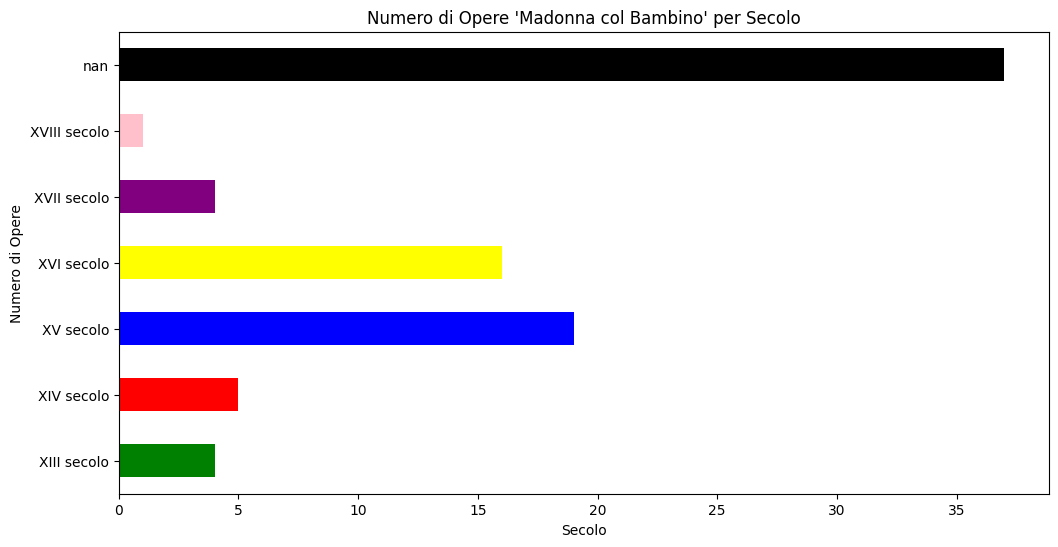

In [ ]:
secoli_count.plot.barh(
    title="Numero di Opere 'Madonna col Bambino' per Secolo",
    xlabel="Secolo",
    ylabel="Numero di Opere",
    figsize=(12, 6),
    color=['green', 'red', 'blue', 'yellow', 'purple', 'pink', 'black',]
)

Visualizzando il grafico a barre è possibile giungere ad alcune prime considerazioni utili per il proseguo della ricerca.
Il primo dato evidente è quello inerente alle opere senza un'indicazione della data di creazione che nello specifico sono 37.
Il secolo nel quale invece sono state prodotte il maggior numero di opere con una rappresentazione iconografia della Madonna con il Bambino è il XV secolo durante il quale sono state prodotte 20 opere.

Nel proseguimento della nostra ricerca sulla base dei risultati ottenuti focalizzeremo la nostra analisi dei dati per rispondere ai ulteriori obbiettivi della ricerca  ponendo la nostra attenzione sulle opere prodotte durante il XV secolo e quelle in cui la data di produzione non è specificata in quanto sono i dati più rilevanti.

### 4.3 Analisi dei generi, movimenti artistici e collezioni di conservazione


Abbiamo creato un nuovo dataframe assegnandogli la variabili `df_MADONNA`nel quale vengono prese in considerazione solamente le opere create nel XV secolo o con la data di creazione non definita (questi erano evidenziati come la maggior parte).

In [ ]:
df_MADONNA = df_madonna[df_madonna['secolo'].str.contains('XV secolo|nan', na=False)]

In [ ]:
df_MADONNA

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,contenuti_filtrati,secolo
9,http://www.wikidata.org/entity/Q580853,Madonna col Bambino degli Innocenti,Sandro Botticelli (maschio),1465,arte religiosa,Spedale degli Innocenti,Museo degli innocenti,Maria; madre; angelo; Bambino Gesù; Madonna co...,Primo Rinascimento,Madonna col Bambino,87.0,60.0,idoneo,XV secolo
19,http://www.wikidata.org/entity/Q1111232,Madonna col Bambino,Jacopo Bellini (maschio),1450,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; donna; madre; ragazzo; aureola; Bambino...,NaN,Madonna col Bambino,69.0,49.0,idoneo,XV secolo
86,http://www.wikidata.org/entity/Q2268013,Madonna col Bambino e due angeli,Sandro Botticelli (maschio),1460,arte religiosa,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,Maria; angelo; Bambino Gesù,Primo Rinascimento,Madonna col Bambino,100.0,71.0,idoneo,XV secolo
129,http://www.wikidata.org/entity/Q3213778,"Madonna col Bambino, due angeli e Giovanni Bat...",Sandro Botticelli (maschio),1470,arte religiosa,Ospedale di Santa Maria Nuova; Galleria dell'A...,Galleria dell'Accademia,Maria; angelo; Bambino Gesù; Madonna col Bambi...,Primo Rinascimento,Madonna col Bambino,85.0,62.0,idoneo,XV secolo
182,http://www.wikidata.org/entity/Q3842472,Madonna col Bambino,Filippo Lippi (maschio),1450,arte religiosa,Fondazione Magnani-Rocca,Fondazione Magnani-Rocca,Maria; ragazzo; madre; Bambino Gesù,NaN,Madonna col Bambino,80.0,52.5,idoneo,XV secolo
183,http://www.wikidata.org/entity/Q3842484,Madonna col Bambino,Giovanni Bellini (maschio),1450,arte religiosa,Pinacoteca Malaspina,Pinacoteca Malaspina,Maria; libro; Bambino Gesù; Targhetta; Madonna...,NaN,Madonna col Bambino,47.0,31.5,idoneo,XV secolo
187,http://www.wikidata.org/entity/Q3842438,"Madonna col Bambino, santi, angeli e donatore",Filippo Lippi (maschio),1432,arte religiosa,Palazzo Cini,Galleria di Palazzo Cini; Collezione Vittorio ...,Maria; Pietro; Giovanni Battista; Stefano; Ant...,NaN,Sacra conversazione,47.0,36.0,idoneo,XV secolo
202,http://www.wikidata.org/entity/Q3842533,Madonna col Bambino e un angelo,Vincenzo Foppa (maschio),1479,arte religiosa,Pinacoteca del Castello Sforzesco,Palazzo degli Uffizi; Pinacoteca del Castello ...,Maria; libro; piante; tenda; finestra; angelo;...,NaN,Madonna col Bambino,41.0,32.5,idoneo,XV secolo
204,http://www.wikidata.org/entity/Q3842577,Madonna col Bambino tra i santi Girolamo e Ber...,Luca Signorelli (maschio),1492,arte religiosa,Palazzo Corsini al Parione,Palazzo Corsini al Parione,Maria; donna; ragazzo; madre; Sofronio Eusebio...,NaN,Madonna col Bambino,112.0,112.0,idoneo,XV secolo
205,http://www.wikidata.org/entity/Q3842594,Madonna col Bambino tra le sante Caterina e Ma...,Giovanni Bellini (maschio),1490,arte religiosa,NaN,Gallerie dell'Accademia,Maria; donna; ragazzo; madre; capelli lunghi; ...,pittura veneta; Primo Rinascimento,Sacra conversazione,58.0,107.0,idoneo,XV secolo


Controlliamo la nuova tabella utilizzando il metodo `.shape` che ci ritorna che la tabella ha 56 righe e 14 colonne. Tale dato è conforme con i dati riscontrati nel grafico a barre.

In [ ]:
df_MADONNA.shape

(56, 14)

Abbiamo individuato quanti valori unici sono presenti nel dataframe `df_Madonna` usando il metodo `.unique()` che ci ha ritornato che i generi che maggiormente riproducono l'iconografia della Madonna con il Bambino.
Tale funzione ci ha ritornato che l'unico genere è quello dell'arte religiosa insieme al valore non definito.

In [ ]:
df_MADONNA['generi'].unique()

array(['arte religiosa', nan], dtype=object)

Dopo abbiamo analizzato nello specifico le quantità di opere con genere  arte religiosa e quelle con valore nullo.

In [ ]:
generi_count = df_MADONNA['generi'].value_counts(dropna=False)
display(generi_count)

,count
generi,
arte religiosa,36
NaN,20


Abbiamo individuato quanti valori unici sono presenti nel dataframe `df_Madonna` usando il metodo `.unique()` sulla colonna `i movimenti` che ci ha ritornato che l'arte religiosa (a parte dei movimenti non-definiti) maggiormente riproduce l'iconografia della Madonna con il Bambino.
Tale funzione ci ha ritornato che `i movimenti` che riproducono tale iconografia nel periodo analizzato sono il 'Primo rinascimento' e la 'pittura veneta; Primo Rinascimento'.

In [ ]:
df_MADONNA['movimenti'].unique()

array(['Primo Rinascimento', nan, 'pittura veneta; Primo Rinascimento'],
      dtype=object)

Successivamente abbiamo analizzato le quantità di opere presenti all'interno dei diversi movimenti identificati.

In [ ]:
movimenti_count = df_MADONNA['movimenti'].astype('str').value_counts().sort_index()

In [ ]:
display(movimenti_count)

,count
movimenti,
Primo Rinascimento,3
nan,52
pittura veneta; Primo Rinascimento,1


Abbiamo individuato quanti valori unici sono presenti nel dataframe `df_Madonna` usando il metodo `.unique()` applicandolo sulla colonna 'collezioni'. Il metodo ci ha ritornato le collezioni che conservono le opere con l'iconografia della Madonna con il Bambino.
Tale funzione ci ha ritornato numerose collezioni in cui sono conservate le opere di tale iconografia nel periodo analizzato (XV secolo e data non definita). Data la quantità di dati abbiamo deciso di disporli in una tabella per rendere più chiara la disposizione e poter analizzare meglio tali dati.

In [ ]:
df_MADONNA['collezioni'].unique()

array(['Museo degli innocenti', 'Palazzo degli Uffizi',
       'Museo nazionale di Capodimonte', "Galleria dell'Accademia",
       'Fondazione Magnani-Rocca', 'Pinacoteca Malaspina',
       'Galleria di Palazzo Cini; Collezione Vittorio Cini',
       'Palazzo degli Uffizi; Pinacoteca del Castello Sforzesco',
       'Palazzo Corsini al Parione', "Gallerie dell'Accademia",
       'Accademia Carrara', 'Galleria di Palazzo Cini',
       'Collezione Vittorio Cini; Galleria di Palazzo Cini',
       'palazzo Bianco', 'chiesa di San Francesco della Vigna',
       'Museo di Castelvecchio', "chiesa di Santa Caterina d'Alessandria",
       'Museo diocesano (Genova)',
       'Museo del Cenacolo di Andrea del Sarto', 'Musei di Strada Nuova',
       "Galleria nazionale dell'Umbria",
       'Pinacoteca Nazionale di Bologna',
       "Galleria Giorgio Franchetti alla Ca' d'Oro",
       'chiesa di Santa Maria in Vallicella', 'Palazzo Pubblico',
       'Pinacoteca nazionale di Siena', 'Museo della catted

Successivamente analizziamo la lista delle collezioni con le opere in questione al loro interno.

Usando la funzione `.value_counts()` otteniamo la tabella nella quale vengono rappresentati le quantità specifiche di opere rappresentanti l'iconografia della Madonna con il Bambino all'interno delle diverse collezioni.

Attraaverso la funzione `.plot` importiamo la libreria per creare la rappresentazione visiva nella forma del graffico a barre orientato orizzontalmente usando la funzione `.barh()` per rendere in maniera chiara i risultati ottenuti.

In [ ]:
collezioni_count = df_MADONNA['collezioni'].astype('str').value_counts().sort_index()

In [ ]:
display(collezioni_count)

,count
collezioni,
Accademia Carrara,1
Accademia dei Concordi di Rovigo,1
"Civica Pinacoteca ""il Guercino""",1
Collezione Vittorio Cini; Galleria di Palazzo Cini,3
Fondazione Magnani-Rocca,1
Galleria Estense,3
Galleria Giorgio Franchetti alla Ca' d'Oro,1
Galleria dell'Accademia,1
Galleria di Palazzo Cini,2


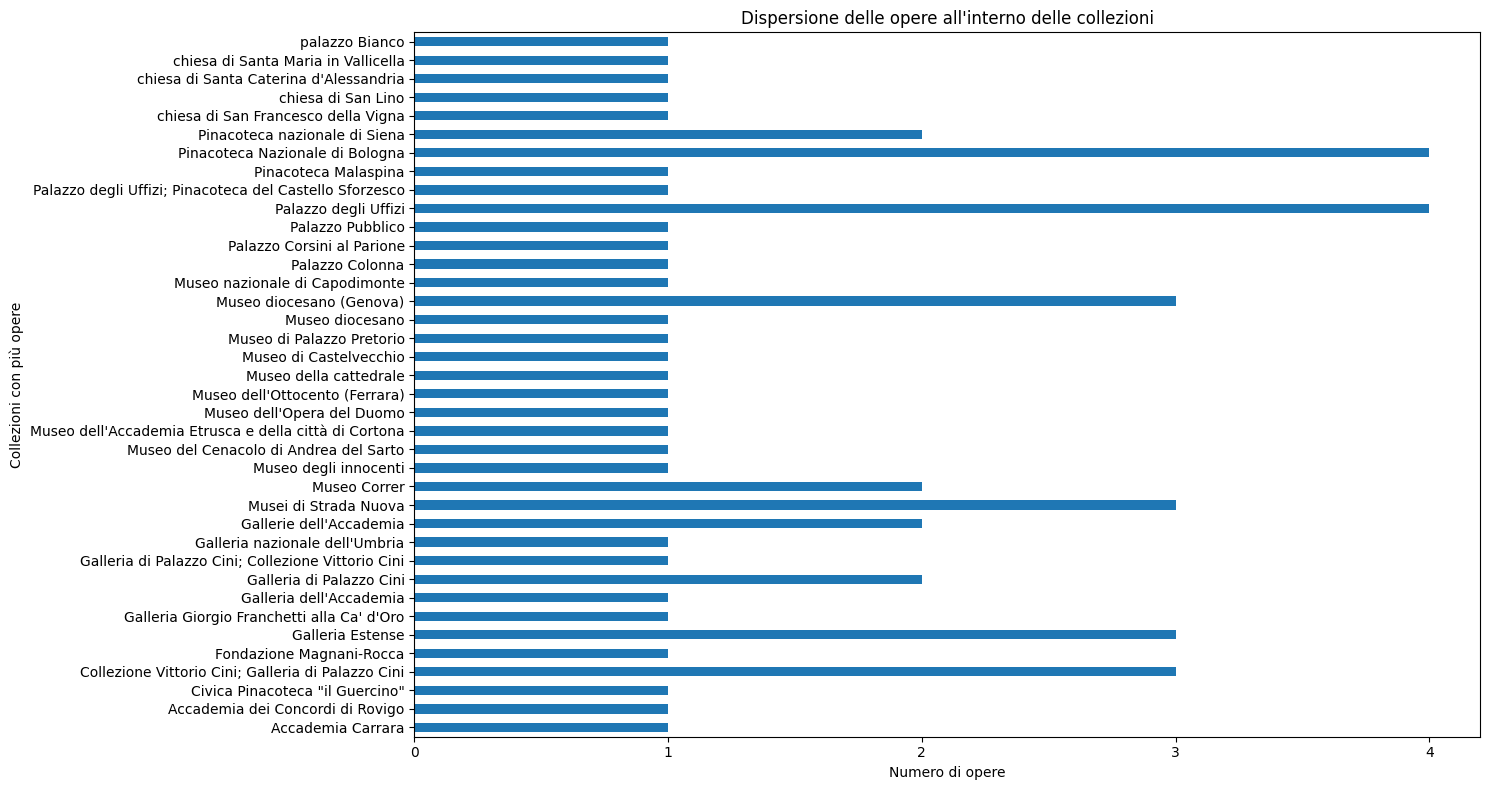

In [ ]:
import matplotlib.pyplot as plt

ax = collezioni_count.plot.barh(
    title="Dispersione delle opere all'interno delle collezioni",
    xlabel="Numero di opere",
    ylabel="Collezioni con più opere",
    figsize=(15,8)
)

# Set x-axis ticks to display only integer values
ax.set_xticks(range(int(collezioni_count.max()) + 1))

plt.tight_layout()
plt.show()

Da tale analisi si evince una dispersione delle opere lungo tutta la penisola italiana con una serie di collezioni che ne detengono solamente 1 ma anche alcune come Museo diocesano (Genova), Musei di Strada Nuova, Galleria Estense, Collezione Vittorio Cini; Galleria di Palazzo Cini che ne hanno 3. Il numero maggiore delle opere in questione è conservato nella Pinacoteca Nazionale di Bologna e Palazzo degli Uffizi, quali ne hanno 4.

### 4.4 Ricerca degli autori più prolifici

In questa ultima parte analizzando il dataframe `df_MADONNA` prodotto in precedenza sulla base del nostro dataset storico-artistico attuiamo una ricerca con l'obbiettivo di trovare tra le opere precedentemente individuate quale siano gli autori più prolifici.  



Inanzitutto  individuiamo gli artisti presenti nel dataset utilizzando il metodo `.value_counts()` poi li abbiamo organizzati in ordine alfabetico usando il metodo `.sort_index()`.

In [ ]:
artisti = df_MADONNA['artisti'].astype('str').value_counts().sort_index()

In [ ]:
display(artisti)

,count
artisti,
Agnolo Gaddi (maschio),1
Ambrogio Lorenzetti (maschio),1
Annibale Carracci (maschio),1
Antonello da Messina (maschio),1
Antonio da Negroponte (maschio),1
Bartolomeo Caporali (maschio),1
Bartolomeo Vivarini (maschio),1
Carlo Maratta (maschio),1
Domenico Panetti (maschio),2


Per visualizzare i risultati ottenuti abbiamo scelto come grafico che esprimesse tali ricultati in maniera chiara quello a torta prima importando la libreria usando `.plot` poi specificando il tipo di grafico attraevrso il codice `.pie()`.
Il grafico è stato intitolato 'Suddivisione delle opere per artista' e la dimensione del grafico è `figsize=(20,20)` e attraverso la funzione `autopct` abbiamo aggiunto la percentuale attribuita ai singoli artisti.

<Axes: title={'center': 'Suddivisione delle opere per artista'}>

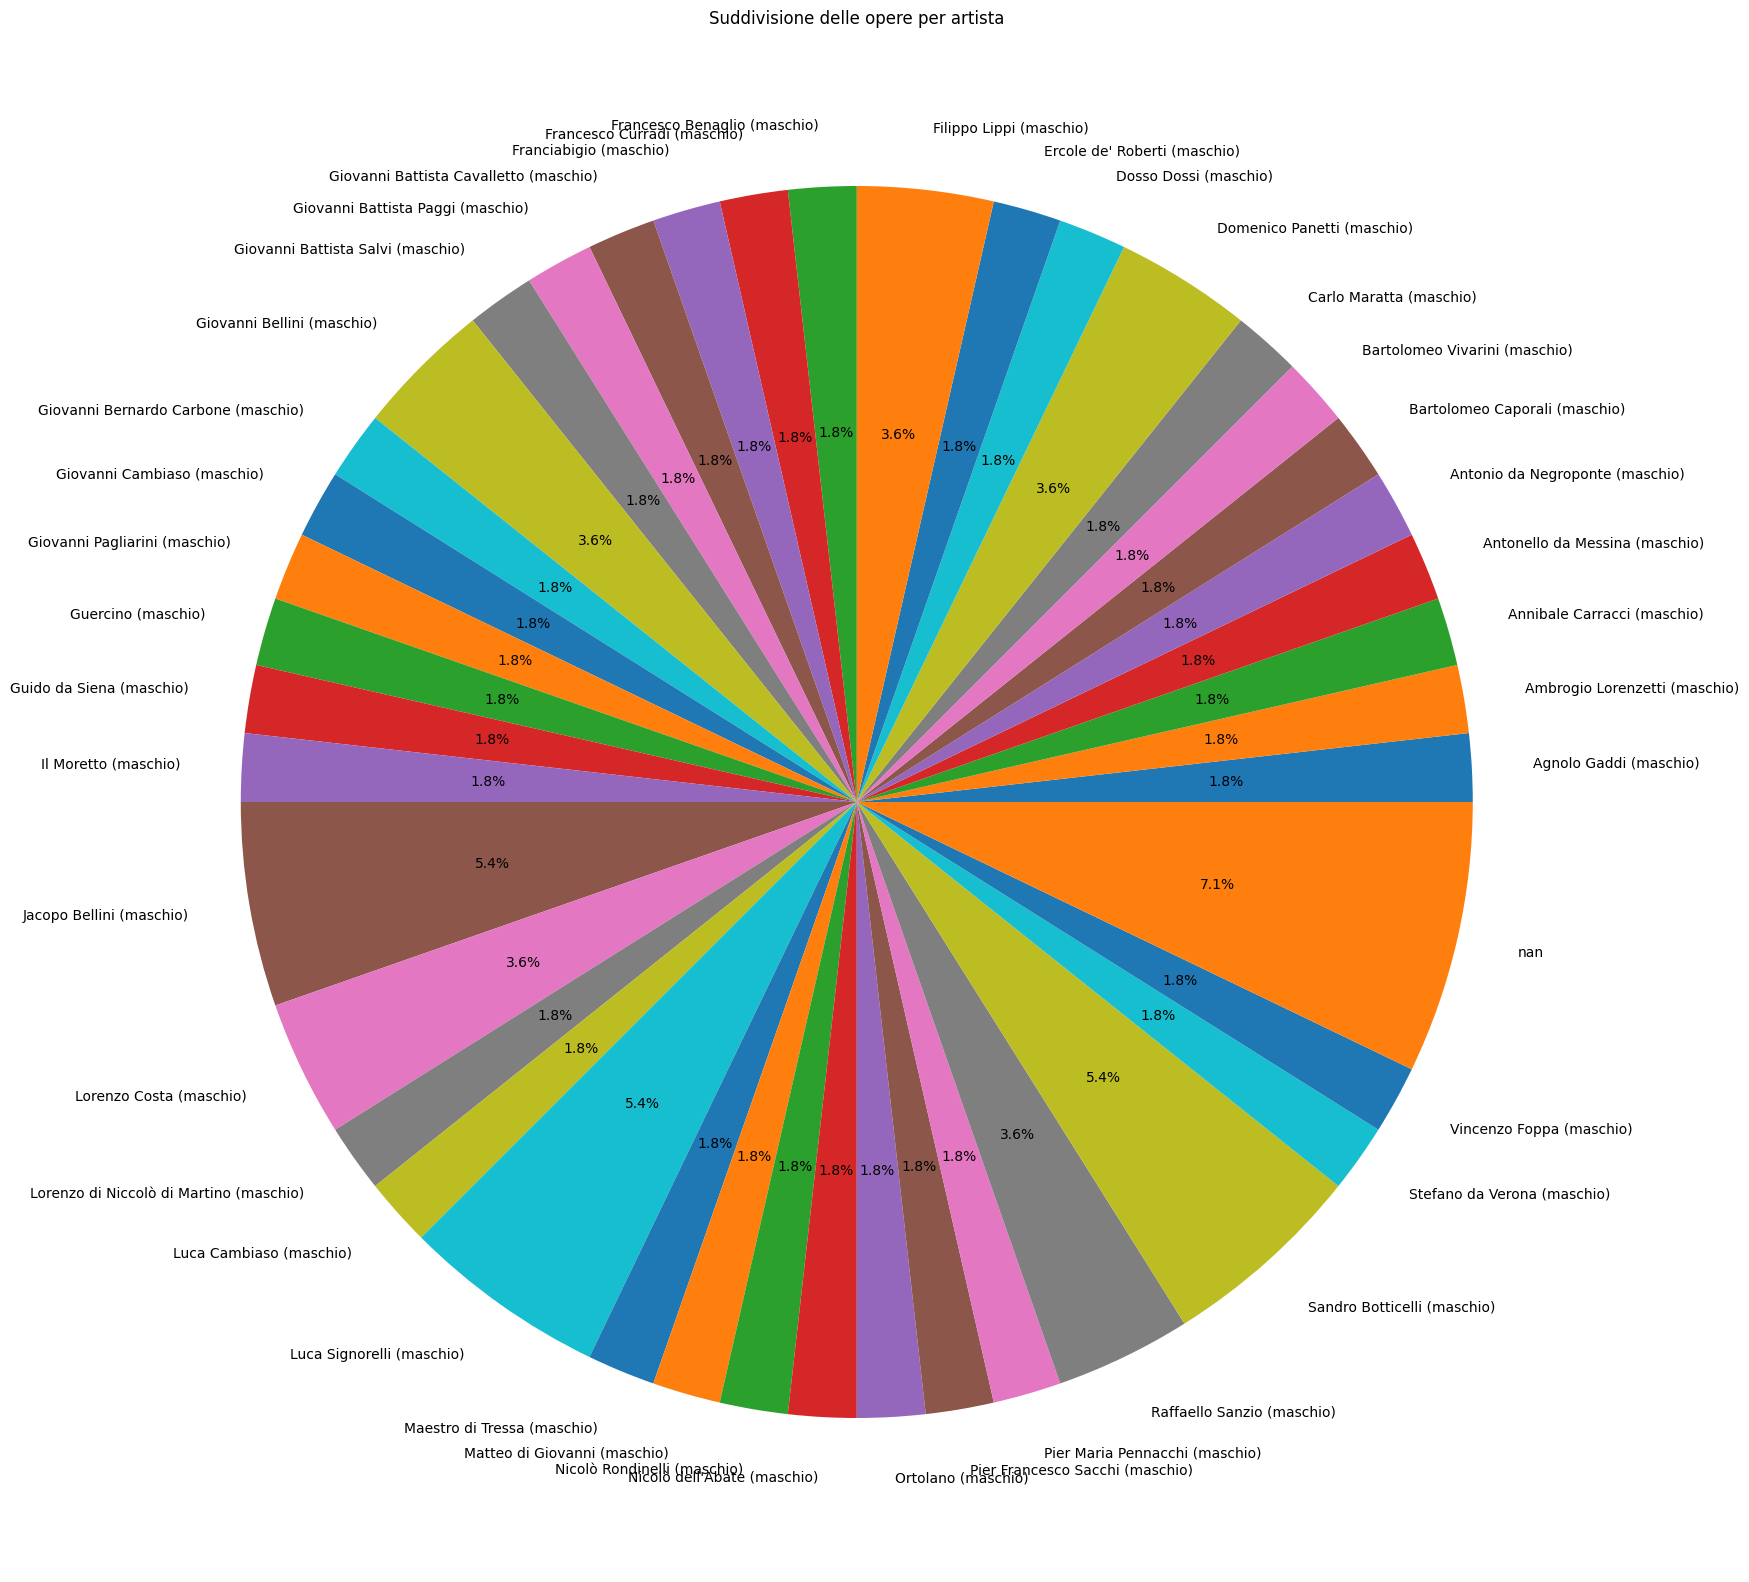

In [ ]:
artisti.plot.pie(
    title="Suddivisione delle opere per artista",
    xlabel="",
    ylabel="",
    figsize=(20, 20),
    autopct='%1.1f%%',
)

Tale rappresentazione visiva elaborata attraverso il grafico a torta rende evidente una serie di dati. Il numero di artisti non identificati rappresenta il 7,1 % del totale mentre gli artisti più prolici sono vari.
Sandro Botticelli, Luca Signorelli e Jacopo Bellini hanno prodotto il 5,4% mentre Giovanni Bellini, Filippo Lippi, Raffello Sanzio e Lorenzo Costa hanno prodotto il 3,6% delle opere.

## 5. Conclusione
In conclusione, possiamo elborare un discorso finale sulla base dei risultati prodotti dalle analisi fatte partendo dalle domande di ricerca.
Nella prima parte abbiamo denotato come le opere che rappresentano l'iconografia della Madonna con il Bambino abbiamo in comune alcuni aspetti come per esempio i protagonisti e gli elementi al loro interno descritti nel dataset attraverso una serie di nomenclature che si ripetono (esempio: Gesù, Madonna, Bambino).
Successivamente rispondendo alla domanda di quali fossero i secoli dove vennero prodotte la maggior parte di queste opere abbiamo denotato come il secolo in cui queste vennero maggiormente prodotte fù il XV secolo, ma anche il fatto che in numerose opere non sia identificato il periodo di creazione.
Dopodichè abbiamo individuato i generi, i movimenti artistici e le collezioni in modo tale poter trovare una correlazione ma tale ricerca ci ha aiutato solamente ad una comprenesione generale che il genere era perlopiù arte religiosa e che i movimenti prevalenti sono Il Primo Rinascimento e la pittura Veneta del Primo rinascimento.
Inoltre durante questo processo abbiamo evidenziato anche una numerosa presenza di dati non definiti che quindi lasciano una serie di incertezze sulla veridicità dei dati riscontrati.
Per quanto riguarda le collezioni abbiamo riscontrato come le opere siano diffuse nelle collezioni lungo tutta la penisola Italiana e le collezioni che ne detengono di più ne hanno 4 e sono la Pinacoteca di Bologna e gli Uffizi.
In ultima istanza abbiamo individuato gli artisti cercando di capire quale sia  stato l'artista più prolifico in questo campo (pur riscontrado anche qui una consistente presenza di valori nulli) è evidente come questa corrente iconografica fosse diffusa in diverse scuole artistiche italiane e che tale iconografia sia stata riprodotta da numerosi artisti durante il XV secolo  che prediligevano il genere della pittura religiosa nell'ambito del periodo del Primo rinascimento.